In [1]:
import awkward as ak
import matplotlib.pyplot as plt

## MC Scaling

Rescaling CR region to try and match between data and MC 

Equation for the rescaling is:

$$v_i = \frac{w_i}{N} \left( \epsilon \cdot L \cdot \sigma \right)$$

Where the variables are defined as 
- $w_i$, original un-normalized MC event weight
- $N$, the normalization of the sample (for JZ slices, this is the sum of all un-normalized MC event weights)
- $\sigma$, the inclusive cross-section of the simulated process
- $L_i$, the integrated luminosity of the dataset campaign (e.g. 26 $fb^{-1}$ for MC23a)
- $\epsilon$, the selection efficiency of event filter(s) applied during the event generation chain

These values can be found using AMI. The definition of normalization taken from the [jetetmiss group documentations](https://atlas-jetetmiss.docs.cern.ch/users/QCD-samples/)

These files have gone through the pre-processing steps and are filtered with the CR region cuts that we used in the previous analysis. The rescaled MC weight is calculated in the `../calratio_training_data/training_query.py` code, but is written here. The rescaled MC weight that is done in the `training_query` code does the rescaling on the entire dataset before it's processed. Any rescaling done now would be done on only the jets that made it through our preselection cuts. In certain cases (JZ2 especially) there are very few remaining jets, so this rescaling might not be very accurate.

I believe the correct way to do JZ reweighting is to reweight them on the full dataset, and then apply the processing.

CR specific cuts are as follows:

- J400 HLT Trigger
- $p_{T, leading}$ > 400 GeV
- $p_{T, subleading}$ > 60 GeV
- $| \phi_{Jet, leading} - \phi_{Jet, subleading} | > 3$ - dijects are back to back
- $\frac{p_{T, leading}-p_{T, subleading}}{p_{T, leading}+p_{T, subleading}} < 0.3$ - leading and subleading jets should have balanced pT
- $H_{T, Miss} < 120 GeV$ - low $H_{T, Miss}$ typical of dijet event

As was written in the internal note the 5 leading jets that pass the selection are used in the control region, and then the jet pT range that is used for the control region is between 40-500 GeV to match the range in the training sample

The validity of the control region is checked by comparing the data and MC pT distributions.

Since the control region is used to guard against the network using data/MC mismodeling in the training, we care more about the shape of the distribution and the data/MC distributions can be normalized to the same integral. That said, the problem that we're experiencing here is due to data and MC not having the same distribution shape. 

In [2]:
jz2 = ak.from_parquet("/data/agolub/cr_datasets/jz2_new_rescale_000.parquet")
jz3 = ak.concatenate([ak.from_parquet("/data/agolub/bulk_processed_files/cr/jz3_newreweighted_000.parquet"), 
                            ak.from_parquet("/data/agolub/bulk_processed_files/cr/jz3_newreweighted_001.parquet")])

In [3]:
jz4 = ak.concatenate([
    ak.from_parquet("/data/agolub/bulk_processed_files/cr/jz4_newreweighted_000.parquet"),
    ak.from_parquet("/data/agolub/bulk_processed_files/cr/jz4_newreweighted_001.parquet"),
    ak.from_parquet("/data/agolub/bulk_processed_files/cr/jz4_newreweighted_002.parquet"),
])

The pT range for JZ2 is relatively low (60-120GeV, or so). Therefore, it is unsuprising that not a lot of the JZ2 jets make it past the J400 HLT jet trigger. With the CR preselection cuts, there are only 70 JZ2 jets that remain. This brings up the question of whether or not the jets are actually from real hard scatter, or if they're just pile up jets. We don't need to be including pile up jets. Further studies at the bottom of this notebook ended up showing that about half of the jets from the JZ2 dataset result from pileup.

This was done by using a dR cut of 0.3 between the jet and the corresponding truth jet. Since the truth jet is from hard scatter, if the jet is within a dR 0.3 from the truth jet then we assume the jet is from hard scatter. Otherwise we say it's from pile up. 

In [4]:
# Dataset containing only the jets that were assigned to be from hard scatter (not pileup)
no_pu_jz2 = ak.from_parquet("/data/agolub/cr_datasets/no_pileup_jz2.parquet")

## Calculating Scale Factor

Using code provided by Miles Cochran-Branson


In [5]:
import os
_DEFAULT_PMG_PATH = "/data/agolub/cr_datasets/PMGxsecDB_mc23.txt"

_pmg_cache: dict[str, dict[int, tuple[float, float, float]]] = {}


def _load_pmg_db(pmg_xsec_db: str) -> dict[int, tuple[float, float, float]]:
    """Parse the PMG text file once and cache by path."""

    if pmg_xsec_db not in _pmg_cache:
        db = {}
        with open(pmg_xsec_db) as f:
            raw_header = f.readline().strip()
            col_names = [col.split("/")[0] for col in raw_header.split(":")]
            for line in f:
                fields = line.split()
                if not fields:
                    continue
                row = dict(zip(col_names, fields))
                db[int(row["dataset_number"])] = (
                    float(row["crossSection_pb"]),
                    float(row["kFactor"]),
                    float(row["genFiltEff"]),
                )
        _pmg_cache[pmg_xsec_db] = db
    return _pmg_cache[pmg_xsec_db]


def get_cross_section(
    dsid: int,
    additional_branching_ratio: float | None = None,
    additional_kfactor: float | None = None,
    pmg_xsec_db: str = _DEFAULT_PMG_PATH,
) -> float:
    """Return crossSection_pb * kFactor * genFiltEff [* additional_branching_ratio]."""

    db = _load_pmg_db(pmg_xsec_db)
    if dsid not in db:
        raise ValueError(f"DSID {dsid} not found in {pmg_xsec_db}")
    xsec, kfactor, filteff = db[dsid]
    result = xsec * kfactor * filteff
    if additional_branching_ratio is not None:
        result *= additional_branching_ratio
    if additional_kfactor is not None:
        result += additional_kfactor
    return result


In [6]:
# Getting the cross section value for the different JZ slices using the DSID of the dataset
jz2_cs = get_cross_section(801167)
jz3_cs = get_cross_section(801168)
jz4_cs = get_cross_section(801169)

In [7]:
# Multiplying the cross section by 1/(sum of the mcEventWeight)
scale_jz2 = jz2_cs / sum(jz2.mcEventWeight)
scale_jz3 = jz3_cs / sum(jz3.mcEventWeight)
scale_jz4 = jz4_cs / sum(jz4.mcEventWeight)

print(scale_jz2)
print(scale_jz3)
print(scale_jz4)

# Multiplying the mcEventWeight column by the rescaling factor
# This will give us the weight we can use for plotting
jz2_weights = jz2.mcEventWeight * scale_jz2
jz3_weights = jz3.mcEventWeight * scale_jz3
jz4_weights = jz4.mcEventWeight * scale_jz4

print(jz2_weights)
print(jz3_weights)
print(jz4_weights)

7.4824877e+08
1.6034178e+06
12995.873
[5.58e+04, 5.58e+04, 5.58e+04, 5.58e+04, 5.58e+04, ..., 3.22e+06, 211, 211, 211]
[0.7, 0.7, 0.7, 0.736, 0.736, 0.71, ..., 0.131, 0.131, 0.131, 0.131, 0.131]
[0.00288, 0.00288, 0.00227, 0.00227, ..., 0.00252, 0.0045, 0.0045, 0.0045]


These JZ rescaled mcEventWeights are calculated only with the jets that made it through the preselection cuts. So this is not necessarily scaled correctly (but was how I tried to do this at first, hence keeping it in.)

Plotting the different JZ slice pT rescaled with the 2 different rescaled mcEventWeights to see how they compare

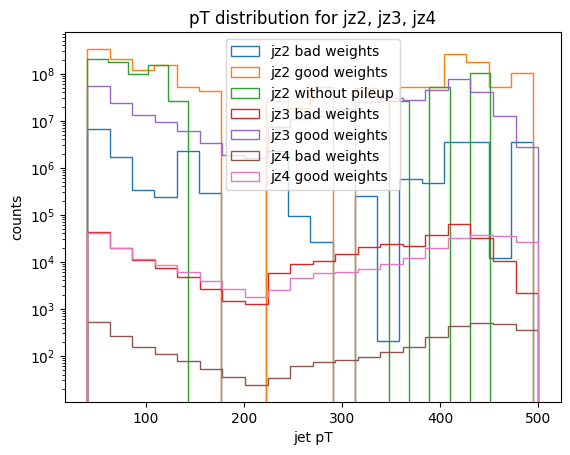

In [11]:
plt.hist(jz2.pt, histtype='step', bins=20, label="jz2 bad weights", weights = jz2_weights)
plt.hist(jz2.pt, histtype='step', bins = 20, label = "jz2 good weights", weights = jz2.rescaled_mcEventWeight)
plt.hist(no_pu_jz2.pt, histtype='step', bins=20, label="jz2 without pileup", weights=no_pu_jz2.rescaled_mcEventWeight)

plt.hist(jz3.pt, histtype='step', bins=20, label="jz3 bad weights", weights = jz3_weights)
plt.hist(jz3.pt, histtype='step', bins = 20, label = "jz3 good weights", weights = jz3.rescaled_mcEventWeight)

plt.hist(jz4.pt, histtype='step', bins=20, label="jz4 bad weights", weights = jz4_weights)
plt.hist(jz4.pt, histtype='step', bins = 20, label = "jz4 good weights", weights = jz4.rescaled_mcEventWeight)

plt.xlabel("jet pT")
plt.ylabel("counts")
plt.yscale("log")
plt.legend()
plt.title("pT distribution for jz2, jz3, jz4")
plt.show()

Focusing in on the JZ2 slice, to see how the distributions change after you get rid of the pile up.

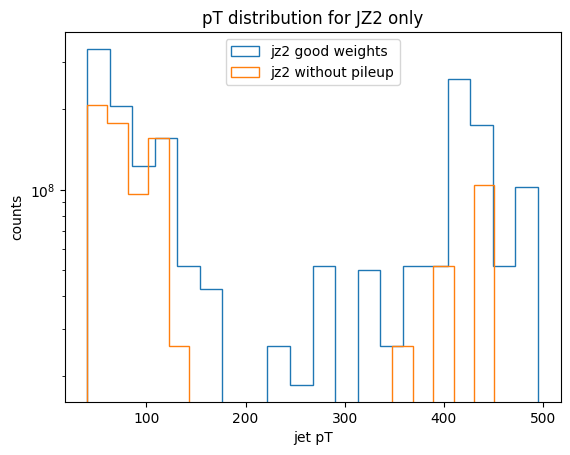

In [14]:
plt.hist(jz2.pt, histtype='step', bins = 20, label = "jz2 good weights", weights = jz2.rescaled_mcEventWeight)
plt.hist(no_pu_jz2.pt, histtype='step', bins=20, label="jz2 without pileup", weights=no_pu_jz2.rescaled_mcEventWeight)

plt.xlabel("jet pT")
plt.ylabel("counts")
plt.yscale("log")
plt.legend()
plt.title("pT distribution for JZ2 only")
plt.show()

Plotting just the 'good' (correct) (probably) weighted pT - including the JZ2 slice that was filtered to not include any pileup

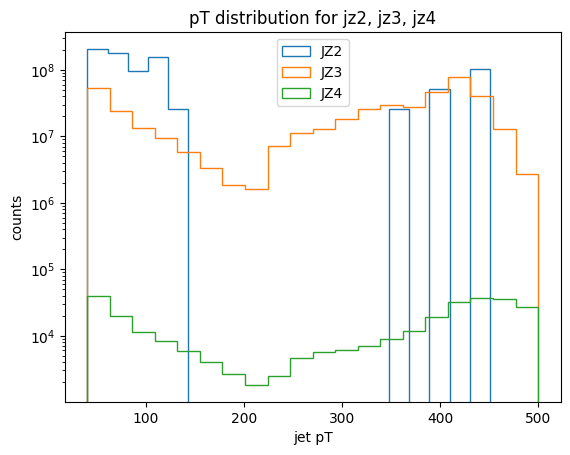

In [15]:
plt.hist(no_pu_jz2.pt, histtype='step', bins=20, label="JZ2", weights=no_pu_jz2.rescaled_mcEventWeight)
plt.hist(jz3.pt, histtype='step', bins = 20, label = "JZ3", weights = jz3.rescaled_mcEventWeight)
plt.hist(jz4.pt, histtype='step', bins = 20, label = "JZ4", weights = jz4.rescaled_mcEventWeight)

plt.xlabel("jet pT")
plt.ylabel("counts")
plt.yscale("log")
plt.legend()
plt.title("pT distribution for jz2, jz3, jz4")
plt.show()

This distribution is aligned with our expectations - JZ4 has the lowest weights, JZ3 has the next highest, and JZ2 has the highest..mostly. There are very few JZ2 samples, I suspect that they'd be weighted a lot higher if there were more than ~35 of them

Plotting weights to see what the distribution of the new weights and the old mcEventWeights look like

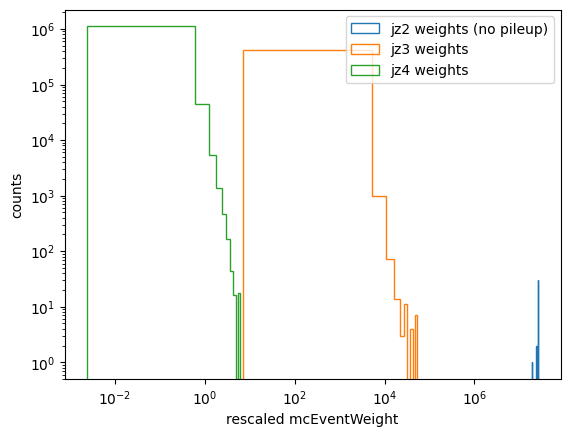

In [19]:
plt.hist(no_pu_jz2.rescaled_mcEventWeight, histtype='step', bins=10, label="jz2 weights (no pileup)")
plt.hist(jz3.rescaled_mcEventWeight, histtype='step', bins=10, label="jz3 weights")
plt.hist(jz4.rescaled_mcEventWeight, histtype='step', bins=10, label="jz4 weights")
plt.xlabel("rescaled mcEventWeight")
plt.ylabel("counts")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.show()

In order to compare the JZ slices and data, we need to combine them. Going to make 2 combined datasets, one with the full (70 jet) JZ2 slice and one with the pile up jets removed from JZ2

In [ ]:
# Combining datasets and weights to plot them
comb = ak.concatenate([jz2, jz3, jz4])
comb_no_pu = ak.concatenate([no_pu_jz2, jz3, jz4])
# The correct weights are in the actual dataset itself
comb_weights = ak.concatenate([jz2_weights, jz3_weights, jz4_weights]) 

Plotting the weighted pT distribution (with the 'correct' reweighting) without any data comparison just to see what it looks like

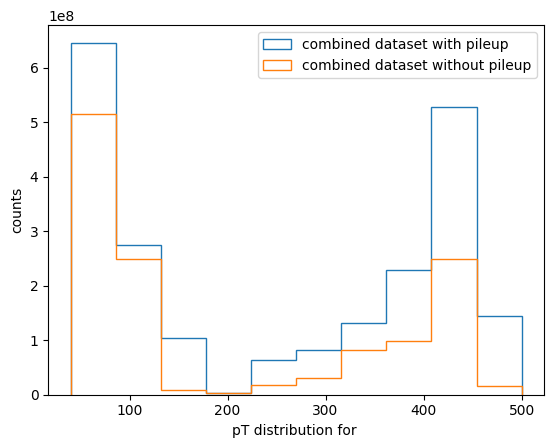

In [23]:
plt.hist(comb.pt, histtype='step', bins=10, label="combined dataset with pileup", weights = comb.rescaled_mcEventWeight)
plt.hist(comb_no_pu.pt, histtype='step', bins=10, label="combined dataset without pileup", weights = comb_no_pu.rescaled_mcEventWeight)
plt.xlabel("pT distribution for ")
plt.ylabel("counts")
plt.legend()
plt.show()

In [30]:
data_ds = ak.from_parquet("/data/agolub/cr_datasets/crdata_test_000.parquet")

In [24]:
import numpy as np

I think that when we're comparing data to MC we want to have a similar amount of data and MC. We'll normalize data and MC together so it really shouldn't make too much of a difference, but right now we have WAY more MC vs data. We have 1,576,600 MC jets and only 248,703 data jets. That said, I'm worried by randomly sampling the MC data we'll lose all of the JZ2 jets...

In [32]:
indices = np.random.permutation(len(data_ds))
comb_sampled = comb[indices]
comb_weights_sampled = comb_weights[indices]
print(len(comb_sampled))

248703


Normalizing the weights: we've got two different kinds of mcWeights we're comparing, the one that was calculated for all of the events before preselection and the one that was calculated earlier in this notebook. We're normalizing these weights for both the sampled and unsampled datasets.

In [59]:
def normalization(un_normalized_weight, data_len):
    # un_normalized_weight: (arr) list of weights
    # data_len: (int) length of the data array we're normalizing to
    normalized_weight = un_normalized_weight * (data_len/sum(un_normalized_weight))
    return normalized_weight

In [60]:
# Sampled weights
norm_sampled_weights = normalization(comb_weights_sampled, len(data_ds))
norm_sampled_rescaled_mcweight = normalization(comb_sampled.rescaled_mcEventWeight, len(data_ds))

# Full dataset weights
norm_weights = normalization(comb_weights, len(data_ds))
norm_rescaled_mcweight = normalization(comb.rescaled_mcEventWeight, len(data_ds))

# Full dataset no pile up weights
norm_rescaled_mcweight_no_pu = normalization(comb_no_pu.rescaled_mcEventWeight, len(data_ds))

We have all of our weights so we're going to start comparing the data and MC pT distributions

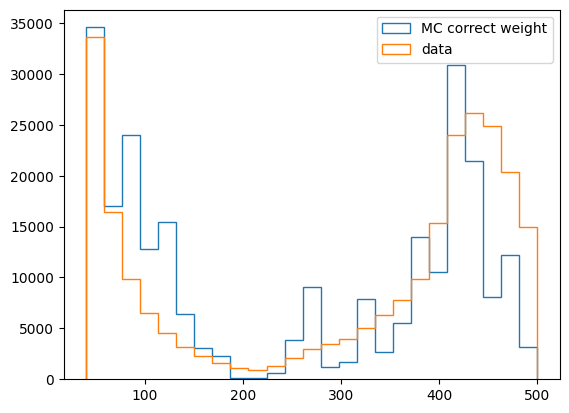

In [61]:
plt.hist(comb.pt, histtype = 'step', weights=norm_rescaled_mcweight, bins=25, label="MC correct weight")
plt.hist(data_ds.pt, histtype="step", label="data", bins = 25)
plt.legend()
plt.show()

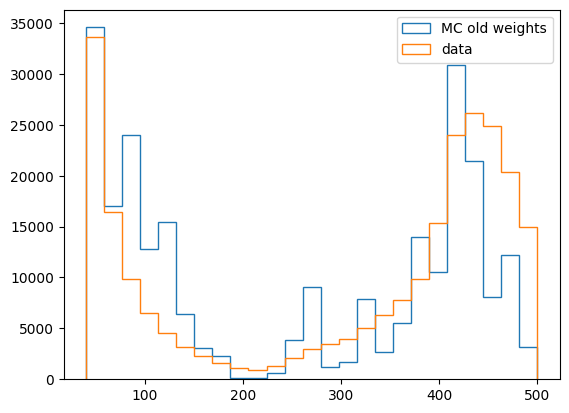

In [62]:
plt.hist(comb.pt, histtype = 'step', weights=norm_rescaled_mcweight, bins=25, label="MC old weights")
plt.hist(data_ds.pt, histtype="step", label="data", bins = 25)
plt.legend()
plt.show()

The 2 plots above both have pile up still in the JZ2 slice, should make the plot again without pile up in JZ2...

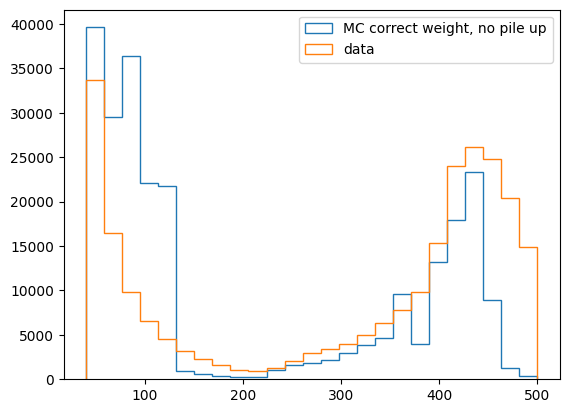

In [63]:
plt.hist(comb_no_pu.pt, histtype = 'step', weights=norm_rescaled_mcweight_no_pu, bins=25, label="MC correct weight, no pile up")
plt.hist(data_ds.pt, histtype="step", label="data", bins = 25)
plt.legend()
plt.show()

Very tragically the distribution for MC and data doesn't line up which is bad. The ones with the correct MC weight does look a little better, and then the one with the pile up removed kind of looks better too (but disappointing because I thought it would fix all my problems and would line up perfectly)

Next cell is a function to make ratio plots, which we can use for a more clear comparison between data and MC

In [64]:
import matplotlib.gridspec as gridspec

def plot_ratio(mc_vals, data_vals, mc_weights, bins=25,
               mc_label="MC", data_label="Data",
               title="", xlabel="$p_T$"):
    mc_vals    = np.asarray(mc_vals)
    data_vals  = np.asarray(data_vals)
    mc_weights = np.asarray(mc_weights)

    bin_range = (min(mc_vals.min(), data_vals.min()),
                 max(mc_vals.max(), data_vals.max()))

    mc_counts,   bin_edges = np.histogram(mc_vals,   bins=bins, range=bin_range, weights=mc_weights)
    mc_var,      _         = np.histogram(mc_vals,   bins=bin_edges, weights=mc_weights**2)
    data_counts, _         = np.histogram(data_vals, bins=bin_edges)

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio     = np.where(mc_counts > 0, data_counts / mc_counts, np.nan)
        ratio_err = np.where(mc_counts > 0, np.sqrt(data_counts) / mc_counts, np.nan)

    fig = plt.figure(figsize=(8, 6))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax_top = fig.add_subplot(gs[0])
    ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

    ax_top.hist(bin_edges[:-1], bin_edges, weights=mc_counts,   histtype='step', label=mc_label)
    ax_top.hist(bin_edges[:-1], bin_edges, weights=data_counts, histtype='step', label=data_label)
    ax_top.legend()
    ax_top.set_ylabel("num jets")
    ax_top.set_title(title)
    plt.setp(ax_top.get_xticklabels(), visible=False)

    ax_bot.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
    ax_bot.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='k.', markersize=4)
    ax_bot.set_xlabel(xlabel)
    ax_bot.set_ylabel("Data / MC")
    ax_bot.set_ylim(0.0, 2.0)

    plt.show()

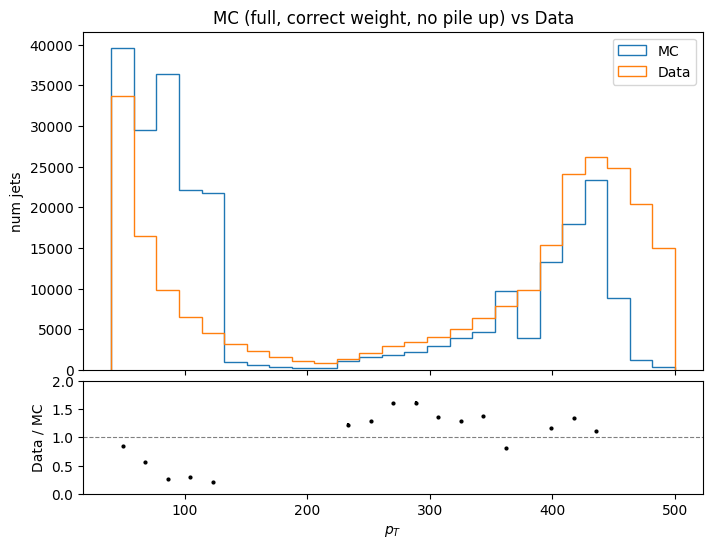

In [65]:
plot_ratio(comb_no_pu.pt, data_ds.pt, norm_rescaled_mcweight_no_pu, title="MC (full, correct weight, no pile up) vs Data")

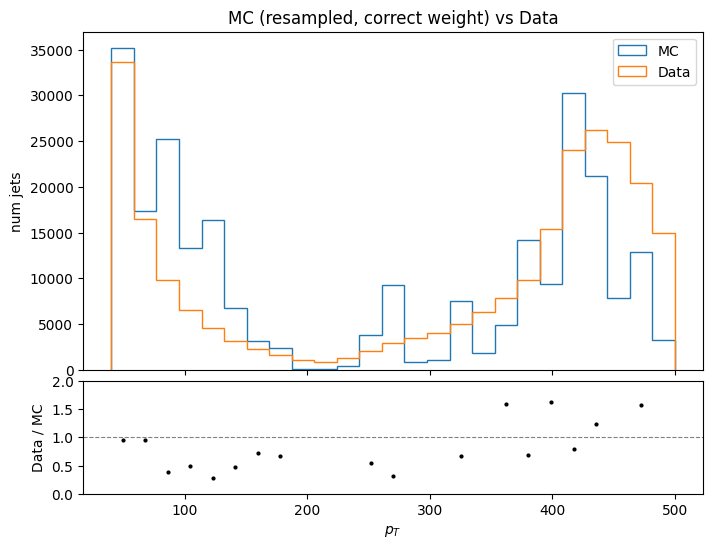

In [66]:
plot_ratio(comb_sampled.pt, data_ds.pt, norm_sampled_rescaled_mcweight, title="MC (resampled, correct weight) vs Data")

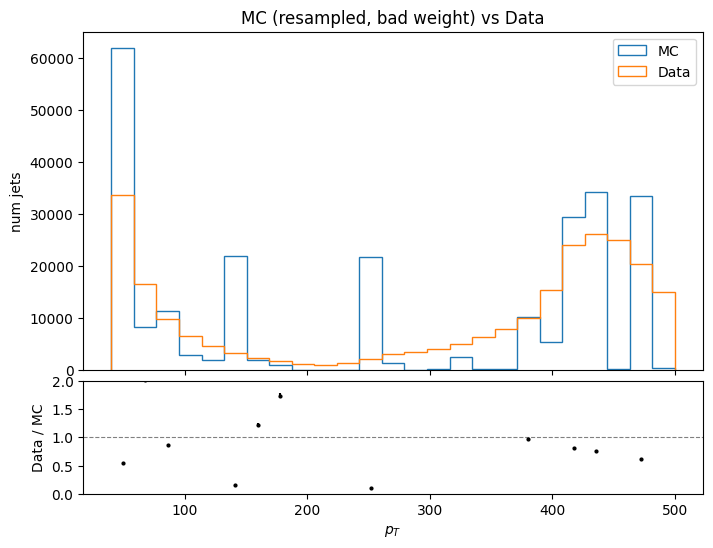

In [67]:
plot_ratio(comb_sampled.pt, data_ds.pt, norm_sampled_weights, title="MC (resampled, bad weight) vs Data")

So, we can see that the correct rescaling does help and indicates that was the correct move, but even the ones that were weighted correctly (labeled with correct weight) are still very different from the data distributions. They're very highly weighted in the low pT regions, which sort of makes sense because that is where we have most of our JZ2 jets, which are more highly weighted than JZ3 or JZ4. That said it still skews the distribution so it's not similar to the data distribution.

Last thing to try - what if we just do not include any JZ2 or JZ3. We should not actually do this, but I just wanted to see what it would look like. 

In [68]:
jz4_weight_norm = normalization(jz4.rescaled_mcEventWeight, len(data_ds))

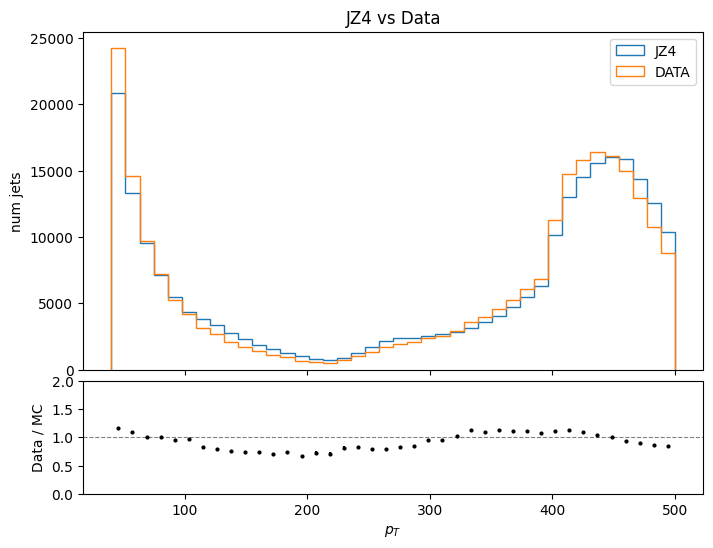

In [69]:
plot_ratio(jz4.pt, data_ds.pt, jz4_weight_norm, 
           mc_label = "JZ4", data_label = "DATA", title = "JZ4 vs Data", bins = 40)

This distribution looks really good but sadly I don't think we should only include JZ4 :/

Next plot is just showing the distributions as they change if we start at a different index, which corresponds with removing some of the JZ2 (and then some of the JZ3) jets. Since we only have ~35 JZ2 jets, if you set i=30 then you're getting rid of most of the JZ2 jets... but this isn't actually motivated by anything that makes sense physically, so this is probably not the right way to go.

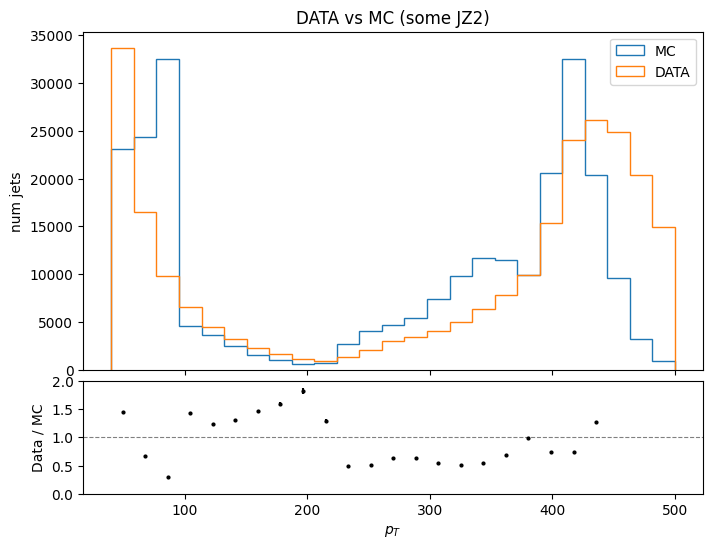

In [74]:
i = 30
plot_ratio(comb_no_pu.pt[i:], data_ds.pt, normalization(comb_no_pu.rescaled_mcEventWeight[i:], len(data_ds)),
           mc_label="MC", data_label="DATA",
           title="DATA vs MC (some JZ2)")

## Decoding where the jets are from in JZ2

The JZ2 jets contain only 70 jets after they go through the cuts. We would expect basically 0 to make it through a J400 trigger. We are trying to figure out what is causing the jets to actually make it through the cut

In [1]:
plt.hist(jz2.jet_partonTruthLabelID)
plt.show()

NameError: name 'plt' is not defined

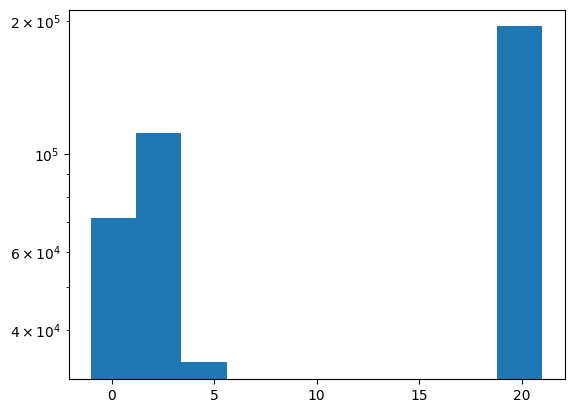

In [ ]:
plt.hist(jz3.jet_partonTruthLabelID)
plt.yscale("log")
plt.show()

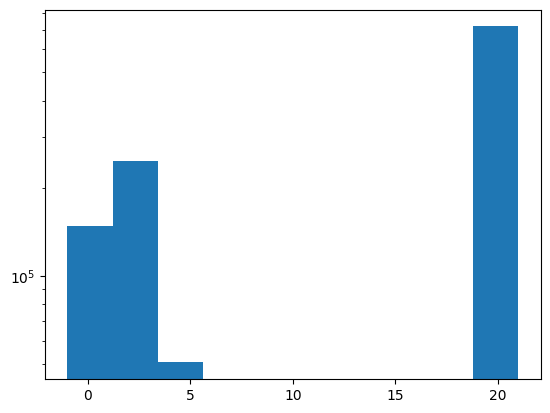

In [ ]:
plt.hist(jz4.jet_partonTruthLabelID)
plt.yscale("log")
plt.show()

These distributions don't seem notably different, but now I have a whole new python script that determines the amount of pile up in the different files. 

The python script is `../jet_origin.py`, and we can run that script to see what percentage of the jets in the processed datasets is pile up. This function essentially finds the dR between the jet and the truth jet. The truth jet is always hard scatter, so if the dR of that jet and truth jet are within 0.3 of each other (arbitrarily picked as a constant), we say that the jet is hard scatter, and if the jet is more than 0.3 away from the truth jet we're saying its from pile up and can be discarded. The script only runs in the command line right now so I've just copy/pasted the results from the script on a JZ2/JZ3/JZ4 dataset.

(Will note that these do not correspond 100% to the datasets that are used earlier in this notebook. This is because in order to get the information necessary for this analysis I had to add some stuff to the `training_query.py` code to do the calculation. This means that older versions of the files are missing the information necessary for doing the pile up analysis, but they're fine for everything else we've been plotting. Basically, just trust me on this)

JZ2:  
Total jets  :       70  
Hard-scatter:       33  (47.1%)  
Pile-up     :       37  (52.9%)  

JZ3:  
Total jets  :   14,179  
Hard-scatter:   13,825  (97.5%)  
Pile-up     :      354  (2.5%)  

JZ4:  
Total jets  :  386,294  
Hard-scatter:  379,811  (98.3%)  
Pile-up     :    6,483  (1.7%)  